In [66]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [67]:
X=2*np.random.randn(100)
y=4+3*X+np.random.randn(100)

<Axes: >

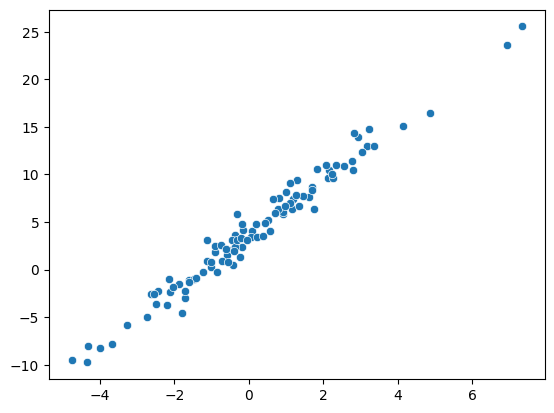

In [68]:
sns.scatterplot(x=X,y=y)

In [69]:
x_mean=X.mean()
y_mean=y.mean()

print("X mean : ", x_mean,"\nY mean : ",y_mean)

X mean :  0.14840833625791103 
Y mean :  4.194486089670885


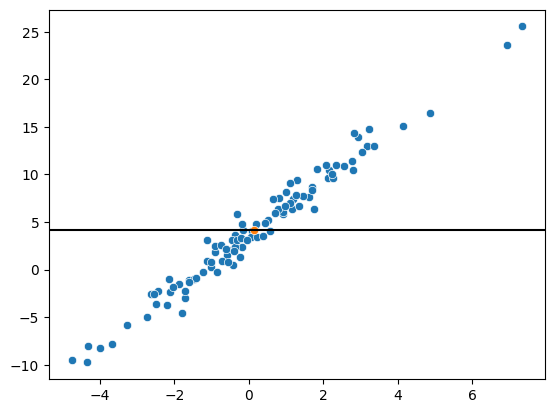

In [70]:
sns.scatterplot(x=X,y=y)
sns.scatterplot(x=[x_mean],y=[y_mean])
plt.axhline(y=y_mean, color="black")
plt.show()

The equation of line is:

y=mx+b

In [71]:
def predict(x,m,b):
    return m*x+b

Loss Function (MSE)

In [72]:
def compute_loss(x,y,m,b):
    n=len(x)
    total_error=0
    for i in range(n):
        y_pred=predict(m,x[i],b)
        error=y[i]-y_pred
        total_error+=error*error
    return total_error/n

Compute Gradients

In [73]:
def compute_gradients(x, y, m, b):
    n = len(x)
    dm = 0
    db = 0

    for i in range(n):
        y_pred = predict(m,x[i],b)
        error = y[i] - y_pred

        dm += -2 * x[i] * error
        db += -2 * error

    dm /= n
    db /= n

    return dm, db

In [74]:
def train(x, y, m, b, alpha, epochs):
    for i in range(epochs):
        dm, db = compute_gradients(x, y, m, b)

        m = m - alpha * dm
        b = b - alpha * db
    return m, b

Test

In [75]:
m=0    # slope
b=0    # intercept

In [76]:
alpha = 0.01   # learning rate
epochs = 1000  # number of iterations

In [77]:
m, b = train(X, y, m, b, alpha, epochs)

Loss

In [78]:
loss=compute_loss(X,y,m,b)
print("Loss is: ",loss)

Loss is:  1.1491960519633269


Best Fit

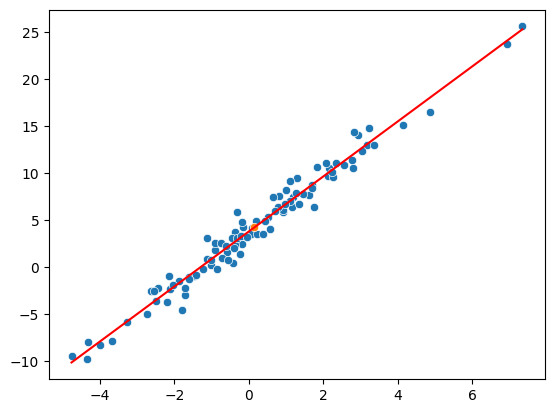

In [79]:
sns.scatterplot(x=X,y=y)
sns.scatterplot(x=[x_mean],y=[y_mean])

x_line = np.linspace(X.min(), X.max(), 100)
y_line = m * x_line + b
plt.plot(x_line, y_line, color='red')
plt.show()

In [80]:
def compute_r2(x, y, m, b):
    n = len(x)
    
    # mean of y
    y_mean = sum(y) / n
    
    ss_res = 0
    ss_tot = 0
    
    for i in range(n):
        y_pred = m * x[i] + b
        
        ss_res += (y[i] - y_pred) ** 2
        ss_tot += (y[i] - y_mean) ** 2
    
    r2 = 1 - (ss_res / ss_tot)
    return r2

In [81]:
r2=compute_r2(X,y,m,b)
print(f"Your model explains {100*r2:.2f}% of variation.")

Your model explains 97.22% of variation.
